# Лабораторная работа №1: Нейронные сети

## Загрузка и предобработка данных

В качестве исходных данных будем использовать датасет *Intel Image Classification* - классификация изображений по мультиклассам

### Скачивание датасета

In [96]:
# Устанавливаем библиотеку для работы с Kaggle
%pip install kagglehub

In [97]:
import kagglehub

# Скачиваем датасет
path = kagglehub.dataset_download("puneet6060/intel-image-classification", )
print("Путь, где находится датасет:", path)

Using Colab cache for faster access to the 'intel-image-classification' dataset.
Путь, где находится датасет: /kaggle/input/intel-image-classification


### Предобработка данных

In [98]:
# Импорт необходимых библиотек
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import os

Определяем пайплайны для обучающей и тестовой выборок

In [99]:
# Трансформации для обучающей выборки
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Трансформации для тестовой выборки
test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

- `transforms.Resize((128, 128))` приводим изображения к единому размеру
- `transforms.RandomHorizontalFlip(p=0.5)` горизонтальное отражение
- `transforms.RandomRotation(15)` небольшой поворот
- `transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2)` небольшие вариации яркости и контраста
- `transforms.ToTensor()` конвертирует PIL Image в в FloatTensor
- `transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])` нормализация каждого канала по статистике ImageNet

## Разделение на обучающую и тестовую выборки

In [100]:
# Путь к изображениям
DATA_DIR = "/kaggle/input/intel-image-classification"

# Формируем обучающий датасет
train_dataset = datasets.ImageFolder(
    root=os.path.join(DATA_DIR, "seg_train", "seg_train"),
    transform=train_transform
)

# Формируем тестовый датасет
test_dataset = datasets.ImageFolder(
    root=os.path.join(DATA_DIR, "seg_test", "seg_test"),
    transform=test_transform
)

print(f"Классы: {train_dataset.classes}")
print(f"Кол-во обучающих изображений: {len(train_dataset)}")
print(f"Кол-во тестовых изображений: {len(test_dataset)}")

Классы: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Кол-во обучающих изображений: 14034
Кол-во тестовых изображений: 3000


In [101]:
# Батчи из 64 изображений
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

- `shuffle=True` указываем в `train_loader`, чтобы батчи формировались в случайном порядке
- `num_workers=2` два фоновых процесса

### Визуализация тестовой выборки

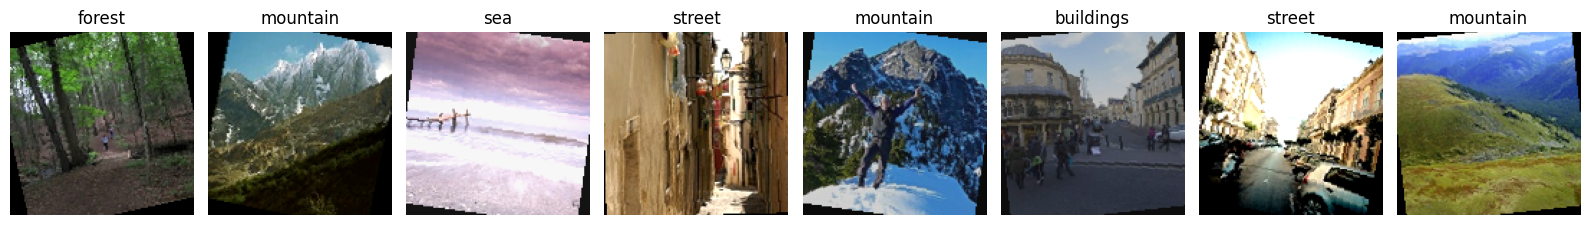

In [102]:
def show_batch(loader, classes, n=8):
    """
    Визуализирует первые восемь изображений из первого батча
    """
    images, labels = next(iter(loader))
    # Денормализация каналов
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    images_denorm = images[:n] * std + mean
    images_denorm = torch.clamp(images_denorm, 0, 1)

    fig, axes = plt.subplots(1, n, figsize=(16, 4))
    for i in range(n):
        axes[i].imshow(images_denorm[i].permute(1, 2, 0).numpy())
        axes[i].set_title(classes[labels[i]])
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()

show_batch(train_loader, train_dataset.classes)

## Построение архитектуры свёрточной нейронной сети

### Архитектура CNN

| Этап | Каналы | Размер | Что происходит |
|------|--------|--------|----------------|
| Вход | 3 | 128 × 128 | RGB картинка |
| После слоя 1 | 32 | 64 × 64 | 32 карты базовых признаков |
| После слоя 2 | 64 | 32 × 32 | 64 карты более сложных признаков |
| После слоя 3 | 128 | 16 × 16 | 128 карт ещё более абстрактных |
| После слоя 4 | 256 | 8 × 8 | 256 карт высокоуровневых признаков |
| Flatten | — | 16 384 | Вектор для классификатора |
| Linear + ReLU + Dropout | — | 512 | Сжатие признаков |
| Linear (выход) | — | 6 | По одному числу на класс |

In [103]:
class CNN(nn.Module):
    def __init__(self, num_classes=6):
        super(CNN, self).__init__()

        # Слой 1: 3 канала -> 32 фильтра
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        # После: 32 x 64 x 64

        # Слой 2: 32 -> 64 фильтра
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        # После: 64 x 32 x 32

        # Слой 3: 64 -> 128 фильтров
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        # После: 128 x 16 x 16

        # Слой 4: 128 -> 256 фильтров
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        # После: 256 x 8 x 8

        # Классификатор
        self.classifier = nn.Sequential(
            nn.Flatten(),                  # Превращает тензор 256×8×8 в вектор длиной 16 384
            nn.Linear(256 * 8 * 8, 512),   # Сжимает 16 384 числа в 512
            nn.ReLU(),                     # Нелинейность между слоями. Обнуляет часть значений
            nn.Dropout(0.5),               # Случайно обнуляет 50% нейронов из 512
            nn.Linear(512, num_classes)    # Финальный слой - 6 выходов по числу классов
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.classifier(x)
        return x

### Проверка

In [104]:
if torch.cuda.is_available:
    print("Используем: cuda")
    device = torch.device("cuda")
else:
    print("Используем: cpu")
    device = torch.device("cpu")

model = CNN(num_classes=6).to(device)

# Проверка выхода модели
dummy = torch.randn(1, 3, 128, 128).to(device)
output = model(dummy)
print(f"Выход модели: {output.shape}")

# Количество параметров
total_params = sum(p.numel() for p in model.parameters())
print(f"Параметров: {total_params:,}")

Используем: cuda
Выход модели: torch.Size([1, 6])
Параметров: 8,781,574


## Обучение и тестирование модели

In [105]:
# Определяем функцию потерь и оптимизатор
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

### Цикл обучения и тестирования

In [106]:
NUM_EPOCHS = 20

train_losses = []
test_losses = []
test_accuracies = []

for epoch in range(NUM_EPOCHS):
    # Обучение
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()                # Обнуляем градиенты
        outputs = model(images)              # Прямой проход
        loss = criterion(outputs, labels)    # Считаем ошибку
        loss.backward()                      # Обратное распространение
        optimizer.step()                     # Обновляем веса

        running_loss += loss.item() * images.size(0)

    epoch_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # Тестирование
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_test_loss = test_loss / len(test_loader.dataset)
    epoch_test_acc = correct / total

    test_losses.append(epoch_test_loss)
    test_accuracies.append(epoch_test_acc)

    print(f"Эпоха [{epoch + 1 if epoch >= 9 else f"0{epoch + 1}"}/{NUM_EPOCHS}]:  "
          f"Ошибка обучения: {epoch_train_loss:.4f} | "
          f"Ошибка обучения: {epoch_test_loss:.4f} | "
          f"Точность теста: {epoch_test_acc:.4f}")

Эпоха [01/20]:  Ошибка обучения: 1.4120 | Ошибка обучения: 0.8483 | Точность теста: 0.6677
Эпоха [02/20]:  Ошибка обучения: 0.8951 | Ошибка обучения: 0.7675 | Точность теста: 0.7243
Эпоха [03/20]:  Ошибка обучения: 0.7909 | Ошибка обучения: 0.6504 | Точность теста: 0.7657
Эпоха [04/20]:  Ошибка обучения: 0.7362 | Ошибка обучения: 0.5457 | Точность теста: 0.8047
Эпоха [05/20]:  Ошибка обучения: 0.6763 | Ошибка обучения: 0.5825 | Точность теста: 0.7927
Эпоха [06/20]:  Ошибка обучения: 0.6382 | Ошибка обучения: 0.5233 | Точность теста: 0.8257
Эпоха [07/20]:  Ошибка обучения: 0.6199 | Ошибка обучения: 0.5791 | Точность теста: 0.7983
Эпоха [08/20]:  Ошибка обучения: 0.5842 | Ошибка обучения: 0.4637 | Точность теста: 0.8393
Эпоха [09/20]:  Ошибка обучения: 0.5567 | Ошибка обучения: 0.5225 | Точность теста: 0.8210
Эпоха [10/20]:  Ошибка обучения: 0.5456 | Ошибка обучения: 0.5204 | Точность теста: 0.8183
Эпоха [11/20]:  Ошибка обучения: 0.5297 | Ошибка обучения: 0.4650 | Точность теста: 0.8473

## Оценка качества классификации на тестовой выборке

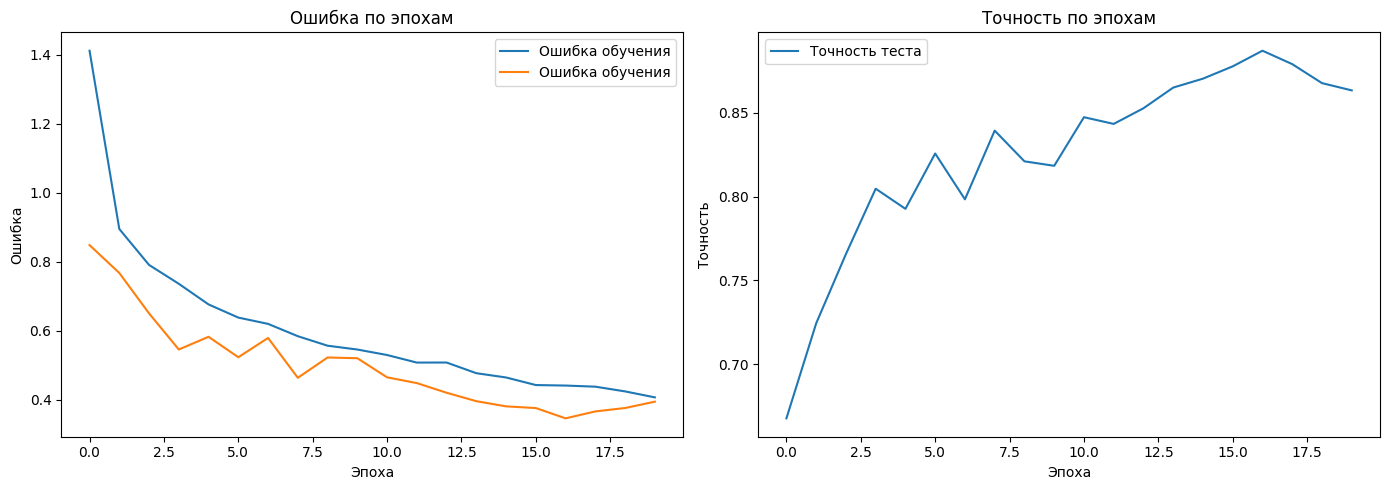

Итоговая точность на тесте: 86.33%


In [107]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label="Ошибка обучения")
ax1.plot(test_losses, label="Ошибка обучения")
ax1.set_xlabel("Эпоха")
ax1.set_ylabel("Ошибка")
ax1.legend()
ax1.set_title("Ошибка по эпохам")

ax2.plot(test_accuracies, label="Точность теста")
ax2.set_xlabel("Эпоха")
ax2.set_ylabel("Точность")
ax2.legend()
ax2.set_title("Точность по эпохам")

plt.tight_layout()
plt.show()

print(f"Итоговая точность на тесте: {test_accuracies[-1]*100:.2f}%")

### Матрица путаницы

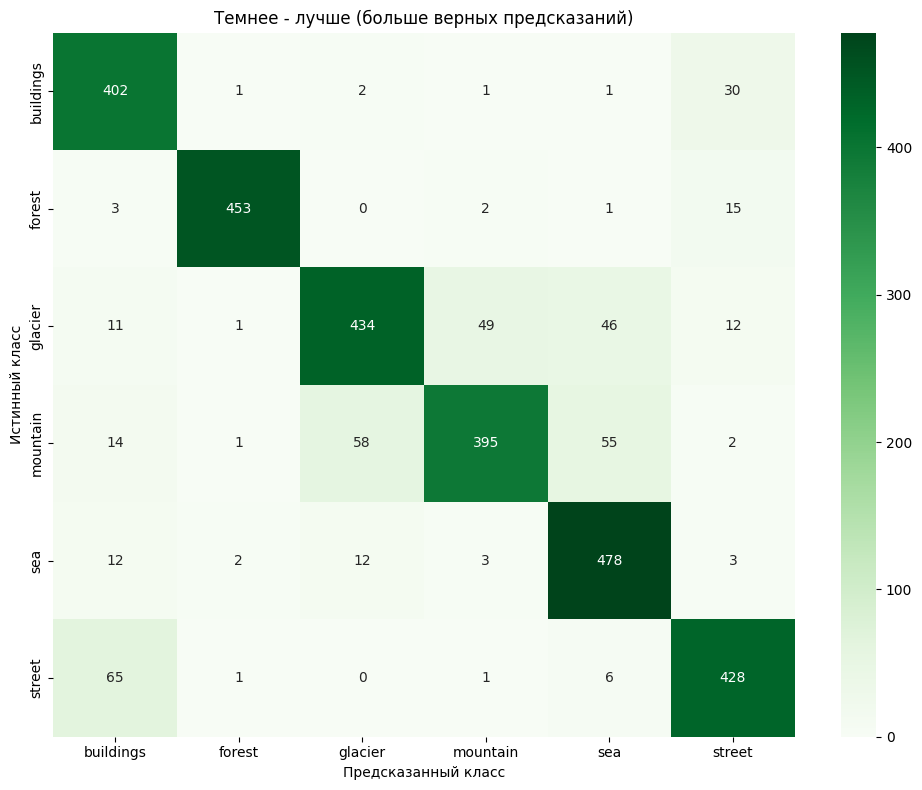

In [108]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
class_names = test_dataset.classes

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.title("Темнее - лучше (больше верных предсказаний)")
plt.tight_layout()
plt.show()

### Вывод по метрикам для каждого класса

In [109]:
print(f'{"Класс":<12} {"Precision":>10} {"Recall":>10} {"Кол-во":>10}')
print('-' * 46)

for i, cls in enumerate(class_names):
    mask = [l == i for l in all_labels]
    tp = sum(1 for p, l in zip(all_preds, all_labels) if p == i and l == i)
    fp = sum(1 for p, l in zip(all_preds, all_labels) if p == i and l != i)
    fn = sum(1 for p, l in zip(all_preds, all_labels) if p != i and l == i)
    support = sum(mask)

    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0

    print(f'{cls:<12} {prec:>10.2f} {rec:>10.2f} {support:>10}')

print('-' * 46)
total = len(all_labels)
acc = sum(1 for p, l in zip(all_preds, all_labels) if p == l) / total
print(f'{"Точность":<12} {"":>10} {"":>10} {total:>10}')

Класс         Precision     Recall     Кол-во
----------------------------------------------
buildings          0.79       0.92        437
forest             0.99       0.96        474
glacier            0.86       0.78        553
mountain           0.88       0.75        525
sea                0.81       0.94        510
street             0.87       0.85        501
----------------------------------------------
Точность                                 3000


- `Precision` - какая доля предсказаний этого класса оказалась верной
- `Recall` - какую долю реальных примеров этого класса CNN нашла

# Вывод

На данной лабораторной работе мы ознакомились с базовыми понятиями как устроены нейронные сети. Из чего состоит их архитектура, как происходит предсказание и как правильно обрабатывать данные, на которых нейронная сеть обучается и тестируется. Помимо этого, был подробно рассмотрен класс нейронных сетей для работы с изображениями - CNN. Из каких слоёв она состоит и как эти слои работают.

В ходе выполнения лабораторной работы была реализована собственная CNN, которая способна классифицировать изображения по шести классам. Для неё был подготовлен датасет, обработаны тренировочные и тестовые данные, определены слои, которые последовательно обрабатывают входной батч и идентифицируют изображение.

После создания, обучения и тестирования CNN был проведён анализ качества её предсказаний. По этим оценкам видно, что модель обучилась достаточно хорошо, что подтверждает тестовая выборка (итоговая точность на тесте ~85%). Также замечу, что больше всего трудностей у CNN возникло с классами mountain и glacier, так как фотографии могут быть схожими. Своими результатами доволен.